## Librerias e Importacion de Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.insert(0, ".")
from funciones.dominios import cargar_dominio
from funciones.campos import normalizar_dtypes
from funciones.graficos import (
    preparar_datos_eda,
    grafico_1_pareto_clientes,
    grafico_2_tendencia_trimestral,
    grafico_3_bubble_productos,
    grafico_4_treemap_geografico,
    grafico_5_histogram_productos_por_cliente,
    grafico_6_heatmap_producto_segmento,
    grafico_7_donut_segmentos,
    grafico_8_scatter_regresion,
    grafico_9_area_evolucion_mensual,
    grafico_10_scatter_paises,
    grafico_11_radar_segmentos,
    grafico_12_faceted_boxplots,
    dashboard_overview,
    dashboard_rentabilidad,
)

sns.set_theme(style="whitegrid", palette="husl")


In [9]:
_DATA_PATH = 'data'

clientes_df = pd.read_csv(f'{_DATA_PATH}/clientes.csv')
catalogo_productos_df = pd.read_csv(f'{_DATA_PATH}/catalogo_productos.csv')
transacciones_df = pd.read_csv(f'{_DATA_PATH}/transacciones.csv')

## Consulta de datos y Exploracion

In [10]:
# Flujo completo: normalizar dtypes -> auditar -> construir objetos OOP
dominio = cargar_dominio(clientes_df, catalogo_productos_df, transacciones_df)


RESUMEN GENERAL -> clientes
Filas: 100
Columnas: 6

Columnas:
['id_cliente', 'nombre', 'edad', 'genero', 'pais', 'segmento']

Tipos de datos:
id_cliente     int64
nombre        object
edad           int64
genero        object
pais          object
segmento      object
dtype: object

Primeras filas:
   id_cliente        nombre  edad genero       pais     segmento
0        1001  Cliente_1001    49      F      Chile       Retail
1        1002  Cliente_1002    32      M      Chile  Corporativo
2        1003  Cliente_1003    20      M  Argentina         PYME
3        1004  Cliente_1004    55      F     México         PYME
4        1005  Cliente_1005    43      F     México         PYME

--------------------------------------------------------------------------------
NULOS -> clientes
--------------------------------------------------------------------------------
            nulos  porcentaje_%
id_cliente      0           0.0
nombre          0           0.0
edad            0           0.0
g

In [11]:
# Explorar el dominio
print(f'Clientes: {len(dominio.clientes)}')
print(f'Productos: {len(dominio.productos)}')
print(f'Transacciones: {len(dominio.transacciones)}')
print(f'Data válida: {dominio.es_valido}')

# Navegación por objetos
t = dominio.transacciones[0]
print(f'\nTransaccion {t.id_transaccion}: {t.cliente.nombre} -> {t.producto.nombre_producto} ({t.monto} {t.producto.moneda})')

# Buscar cliente por ID (Rango de 1000 a 1100)
c = dominio.cliente(1100)
print(f'\nCliente {c.id_cliente}: {c.nombre}, {c.edad} años, {len(c.transacciones)} transacciones')

Clientes: 100
Productos: 10
Transacciones: 500
Data válida: True

Transaccion 5001: Cliente_1046 -> Producto_7 (1539.59 EUR)

Cliente 1100: Cliente_1100, 45 años, 5 transacciones


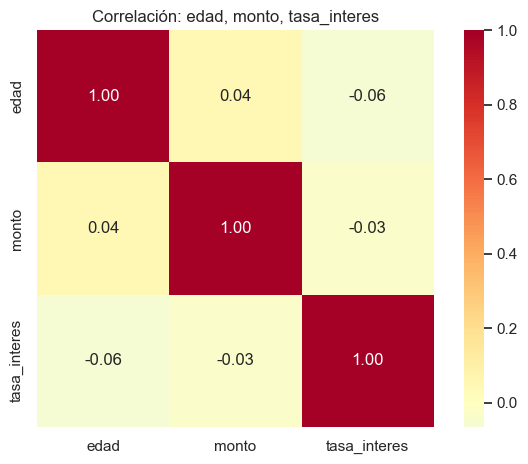

In [ ]:
# Preparación de datos para EDA
clientes = normalizar_dtypes(clientes_df.copy(), "clientes")
productos = normalizar_dtypes(catalogo_productos_df.copy(), "catalogo_productos")
trans = normalizar_dtypes(transacciones_df.copy(), "transacciones")
datos = preparar_datos_eda(clientes, productos, trans)

## EDA — 12 gráficos profesionales

Análisis de transacciones financieras. Cada gráfico responde una pregunta concreta.

In [ ]:
# TIER 1 — Críticos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
grafico_1_pareto_clientes(datos["cliente_volumen"], axes[0, 0])
grafico_2_tendencia_trimestral(datos["trimestral"], axes[0, 1])
grafico_3_bubble_productos(datos["producto_agg"], axes[1, 0])
grafico_4_treemap_geografico(datos["pais_agg"], axes[1, 1])
plt.tight_layout()
plt.show()

In [ ]:
# TIER 2 — Importantes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
grafico_5_histogram_productos_por_cliente(datos["productos_por_cliente"], axes[0, 0])
grafico_6_heatmap_producto_segmento(datos["heatmap"], axes[0, 1])
grafico_7_donut_segmentos(datos["segmento_agg"], axes[1, 0])
grafico_8_scatter_regresion(datos["cliente_agg"], axes[1, 1])
plt.tight_layout()
plt.show()

In [ ]:
# TIER 3 — Complementarios (9, 10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grafico_9_area_evolucion_mensual(datos["mensual"], axes[0])
grafico_10_scatter_paises(datos["pais_scatter"], axes[1])
plt.tight_layout()
plt.show()

# 11. Radar
grafico_11_radar_segmentos(datos["radar"])
plt.show()

# 12. Faceted boxplots
grafico_12_faceted_boxplots(datos["tx_full"])
plt.show()

## Dashboards consolidados

In [ ]:
dashboard_overview(datos)

In [ ]:
dashboard_rentabilidad(datos)